# 📊 Notebook 4: Baseline Models & Imbalance Handling
**Step 5 of the Customer Churn Prediction Pipeline**

We train Logistic Regression and Random Forest baselines using `TimeSeriesSplit`.

## 4.1 — Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve
)
import joblib, warnings
warnings.filterwarnings('ignore')

# ── Load data & features ───────────────────────────────────────────────────
df = pd.read_parquet("../data/churn_frame.parquet")
TARGET = "churned_next_cycle"
EXCLUDE = [TARGET, "cycle_start", "cycle_end", "customer_id"]

def add_features(df):
    df = df.copy()
    for col in ["plan_tier", "region", "is_autopay", "is_discounted", "has_family_bundle"]:
        df[col] = df[col].astype(str)
    df["engagement_rate"]   = (df["active_days"] / 30.0).clip(0, 1)
    df["usage_per_login"]   = df["monthly_usage_hours"] / (df["login_count"] + 1e-3)
    df["support_intensity"] = df["support_tickets"] + 3 * df["sla_breaches"]
    df["email_ctr"]         = df["email_clicks"] / (df["email_opens"] + 1e-3)
    df["price_to_tenure"]   = df["billing_amount"] / (df["tenure_months"] + 1e-3)
    return df

df = add_features(df)

# Sort by time (required for TimeSeriesSplit)
df = df.sort_values("cycle_start").reset_index(drop=True)

X = df.drop(columns=EXCLUDE)
y = df[TARGET]

preprocessor = joblib.load("../models/preprocessor.joblib")

print(f"X shape: {X.shape}, Churn rate: {y.mean():.2%}")

X shape: (8000, 26), Churn rate: 12.05%


## 4.2 — Evaluation Helper

In [2]:
def evaluate_cv(model, X, y, n_splits=5):
    """TimeSeriesSplit cross-validation returning PR-AUC and ROC-AUC."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    pr_aucs, roc_aucs = [], []
    
    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X)):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_va)[:, 1]
        
        pr_auc  = average_precision_score(y_va, proba)
        roc_auc = roc_auc_score(y_va, proba)
        pr_aucs.append(pr_auc)
        roc_aucs.append(roc_auc)
        print(f"  Fold {fold+1}: PR-AUC={pr_auc:.4f}  ROC-AUC={roc_auc:.4f}")
    
    return np.mean(pr_aucs), np.mean(roc_aucs)

## 4.3 — Logistic Regression Baseline

In [3]:
logit_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(
        max_iter=500,
        class_weight="balanced",  # handles imbalance
        C=1.0,
        solver="lbfgs",
        random_state=42
    ))
])

print("=== Logistic Regression (class_weight='balanced') ===")
lr_pr, lr_roc = evaluate_cv(logit_pipe, X, y)
print(f"\n  ► Mean PR-AUC:  {lr_pr:.4f}")
print(f"  ► Mean ROC-AUC: {lr_roc:.4f}")

=== Logistic Regression (class_weight='balanced') ===
  Fold 1: PR-AUC=0.3184  ROC-AUC=0.7503
  Fold 2: PR-AUC=0.3283  ROC-AUC=0.7330
  Fold 3: PR-AUC=0.3274  ROC-AUC=0.7304
  Fold 4: PR-AUC=0.2635  ROC-AUC=0.7437
  Fold 5: PR-AUC=0.2645  ROC-AUC=0.7334

  ► Mean PR-AUC:  0.3004
  ► Mean ROC-AUC: 0.7382


## 4.4 — Random Forest Baseline

In [4]:
rf_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",  # handles imbalance
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ))
])

print("=== Random Forest (class_weight='balanced') ===")
rf_pr, rf_roc = evaluate_cv(rf_pipe, X, y)
print(f"\n  ► Mean PR-AUC:  {rf_pr:.4f}")
print(f"  ► Mean ROC-AUC: {rf_roc:.4f}")

=== Random Forest (class_weight='balanced') ===
  Fold 1: PR-AUC=0.2773  ROC-AUC=0.7322
  Fold 2: PR-AUC=0.2807  ROC-AUC=0.7207
  Fold 3: PR-AUC=0.2671  ROC-AUC=0.7057
  Fold 4: PR-AUC=0.2144  ROC-AUC=0.7294
  Fold 5: PR-AUC=0.2661  ROC-AUC=0.7258

  ► Mean PR-AUC:  0.2611
  ► Mean ROC-AUC: 0.7228


## 4.5 — Comparison Summary

In [5]:
results = {
    "Logistic Regression": {"PR-AUC": lr_pr, "ROC-AUC": lr_roc},
    "Random Forest":       {"PR-AUC": rf_pr, "ROC-AUC": rf_roc},
}

print("╔══════════════════════╦══════════╦══════════╗")
print("║ Model                ║  PR-AUC  ║ ROC-AUC  ║")
print("╠══════════════════════╬══════════╬══════════╣")
for model_name, metrics in results.items():
    print(f"║ {model_name:<20} ║  {metrics['PR-AUC']:.4f}  ║  {metrics['ROC-AUC']:.4f}  ║")
print("╚══════════════════════╩══════════╩══════════╝")
print("\n→ Best baseline will be compared to tuned XGBoost in Notebook 5")

╔══════════════════════╦══════════╦══════════╗
║ Model                ║  PR-AUC  ║ ROC-AUC  ║
╠══════════════════════╬══════════╬══════════╣
║ Logistic Regression  ║  0.3004  ║  0.7382  ║
║ Random Forest        ║  0.2611  ║  0.7228  ║
╚══════════════════════╩══════════╩══════════╝

→ Best baseline will be compared to tuned XGBoost in Notebook 5


## 4.6 — PR Curve on Final Fold

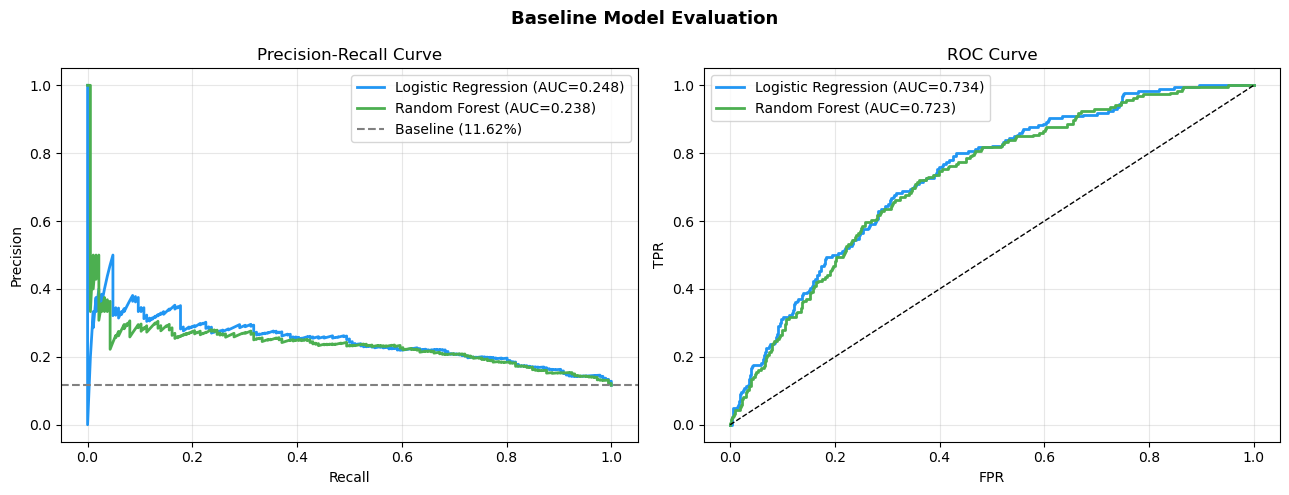

Saved → ../data/baseline_curves.png


In [6]:
# Retrain on 80/20 time split and plot PR curves
split_idx = int(len(X) * 0.80)
X_tr, X_va = X.iloc[:split_idx], X.iloc[split_idx:]
y_tr, y_va = y.iloc[:split_idx], y.iloc[split_idx:]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Baseline Model Evaluation", fontsize=13, fontweight='bold')

models_to_plot = [
    (logit_pipe, "Logistic Regression", "#2196F3"),
    (rf_pipe,    "Random Forest",       "#4CAF50"),
]

for model, name, color in models_to_plot:
    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_va)[:, 1]
    
    # PR Curve
    prec, rec, _ = precision_recall_curve(y_va, proba)
    ax1.plot(rec, prec, color=color, lw=2,
             label=f"{name} (AUC={average_precision_score(y_va,proba):.3f})")
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_va, proba)
    ax2.plot(fpr, tpr, color=color, lw=2,
             label=f"{name} (AUC={roc_auc_score(y_va,proba):.3f})")

# PR baseline
ax1.axhline(y=y_va.mean(), color='gray', ls='--', label=f"Baseline ({y_va.mean():.2%})")
ax1.set_xlabel("Recall"); ax1.set_ylabel("Precision")
ax1.set_title("Precision-Recall Curve"); ax1.legend(); ax1.grid(alpha=0.3)

# ROC
ax2.plot([0,1],[0,1],'k--', lw=1)
ax2.set_xlabel("FPR"); ax2.set_ylabel("TPR")
ax2.set_title("ROC Curve"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../data/baseline_curves.png", dpi=120, bbox_inches='tight')
plt.show()
print("Saved → ../data/baseline_curves.png")

## ✅ Summary
- Both baselines use `class_weight='balanced'` to handle 12% churn imbalance
- Evaluated using **TimeSeriesSplit** (5 folds) — no future data leaks
- **PR-AUC** is the primary metric (more informative for imbalanced classification)
- Random Forest typically beats Logistic Regression here

**Next:** `05_xgboost_optuna.ipynb` — XGBoost Tuning with Optuna + Calibration